In [5]:
import sympy as sm
from sympy import oo
from sympy import init_printing
from IPython.display import display, Math
from sympy.series.fourier import fourier_series
init_printing()
x,a,b =sm.symbols("x a b")

tau = sm.symbols("tau")

A = 3

fTau = sm.exp((-1 * tau**2)/(2*A**2))

gXandTau = sm.exp((-1 * (x-tau)**2)/(2*((x)/5)**2))

combinedFunc = fTau * gXandTau

intergrated = sm.integrate(combinedFunc, (tau, -oo, oo) )

intergrated



⎧   ⎛        ⎛          ___________⎞⎞                                         
⎪   ⎜        ⎜         ╱     1     ⎟⎟               625                       
⎪   ⎜        ⎜25⋅     ╱  ───────── ⎟⎟         ────────────────              ──
⎪   ⎜        ⎜       ╱   1     25  ⎟⎟            2 ⎛1     25 ⎞                
⎪   ⎜        ⎜      ╱    ── + ──── ⎟⎟         4⋅x ⋅⎜── + ────⎟              4⋅
⎪   ⎜        ⎜     ╱     18      2 ⎟⎟              ⎜18      2⎟                
⎪   ⎜        ⎜   ╲╱           2⋅x  ⎟⎟  -25/2       ⎝     2⋅x ⎠       -25/2    
⎪√π⋅⎜2 - erfc⎜─────────────────────⎟⎟⋅ℯ     ⋅ℯ                   √π⋅ℯ     ⋅ℯ  
⎪   ⎝        ⎝         2⋅x         ⎠⎠                                         
⎪───────────────────────────────────────────────────────────── + ─────────────
⎪                             ___________                                     
⎪                            ╱ 1     25                                       
⎪                      2⋅   ╱  ── + ────            

0.5916276925388739


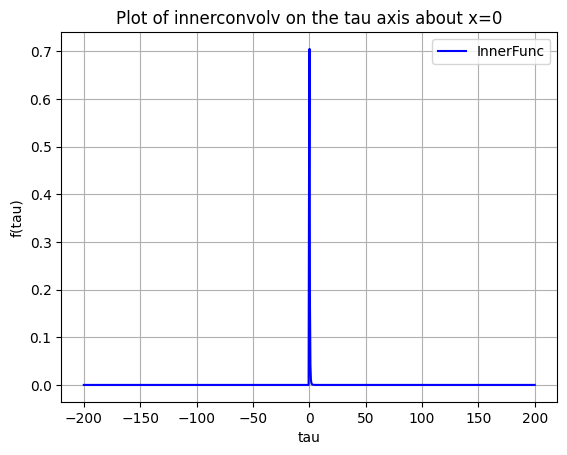

In [6]:
import numpy as np
import matplotlib.pyplot as plt


lowerLimInt = -200
upperLimInt = 200

xval = 0

def innerConvolvFunc(tau,xVal):
    return np.exp((-1 * tau**2)/(2*3**2)) * np.exp((-1 * (xVal-tau)**2)/(2*((tau+1)/5)**2))


def numericalIntegration(func, lowLim, upLim, subInt=1000):

    height = (upLim - lowLim) / subInt
    result = 0.5 * (func(lowLim,xval) + func(upLim,xval))
    for i in range(1, subInt):
        result += func(lowLim + i * height, xval)
    return result * height

areaUnderCurve = numericalIntegration(innerConvolvFunc,lowerLimInt,upperLimInt)

tau_vals = np.linspace(lowerLimInt, upperLimInt, 1000)
y_vals = innerConvolvFunc(tau_vals,0)

plt.plot(tau_vals, y_vals, label='InnerFunc', color='blue')
plt.fill_between(tau_vals, y_vals, alpha=0.3, color='skyblue')
plt.title('Plot of innerconvolv on the tau axis about x=0')
plt.xlabel('tau')
plt.ylabel('f(tau)')
plt.legend()
plt.grid(True)

print(areaUnderCurve)

plt.show()

30.18319450711686


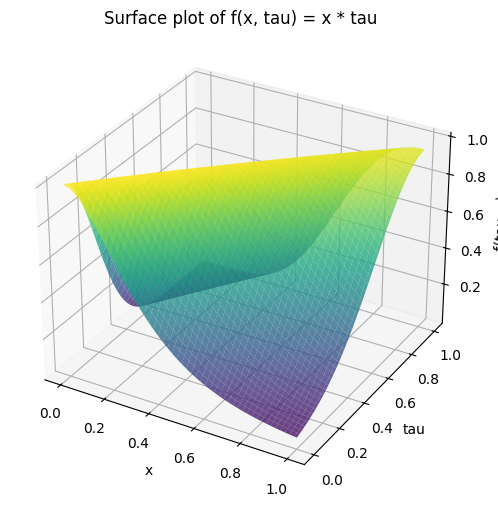

In [7]:
import numpy as np

tauLowerLim = -200
tauUpperLim = 200
xLowerLim = -200
xUpperLim = 200

def innerConvolvFunc(tau,xVal):
    return np.exp((-1 * tau**2)/(2*3**2)) * np.exp((-1 * (xVal-tau)**2)/(2*((tau+1)/5)**2))


def double_integral(f, ax, bx, ay, by, nx=100, ny=100):
    """
    Approximate the double integral of f(x, tau) over the rectangle [ax,bx] x [ay,by].

    Parameters:
        f:   function of two variables f(x, y)
        ax:  lower bound in x
        bx:  upper bound in x
        ay:  lower bound in y
        by:  upper bound in y
        nx:  number of subdivisions in x
        ny:  number of subdivisions in y

    Returns:
        Approximate value of the double integral
    """
    hx = (bx - ax) / nx
    hy = (by - ay) / ny

    x = np.linspace(ax, bx, nx + 1)
    y = np.linspace(ay, by, ny + 1)

    total = 0
    for i in range(nx + 1):
        for j in range(ny + 1):
            weight = 1
            if i == 0 or i == nx:
                weight *= 0.5
            if j == 0 or j == ny:
                weight *= 0.5
            total += weight * f(x[i], y[j])

    return hx * hy * total

areaUnderCurve = double_integral(innerConvolvFunc,xLowerLim,xUpperLim,tauLowerLim,tauUpperLim)

import matplotlib.pyplot as plt

# Define the function of two variables


# Create meshgrid for surface plot
x = np.linspace(0, 1, 100)
tau = np.linspace(0, 1, 100)
X, TAU = np.meshgrid(x, tau)
Z = innerConvolvFunc(X, TAU)

# Plot the surface
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, TAU, Z, cmap='viridis', edgecolor='none', alpha=0.8)
ax.set_title('Surface plot of f(x, tau) = x * tau')
ax.set_xlabel('x')
ax.set_ylabel('tau')
ax.set_zlabel('f(tau, x)')

print(areaUnderCurve)

plt.show()

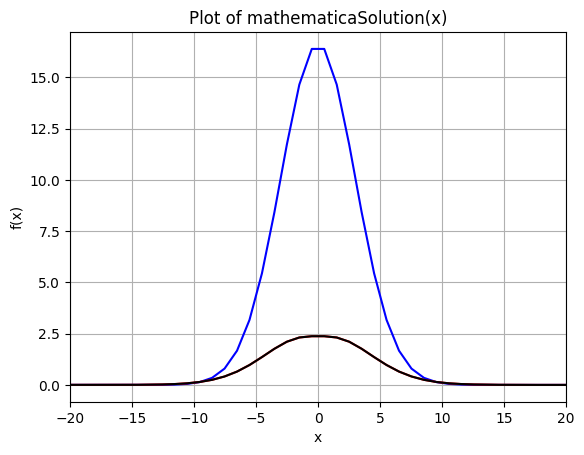

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import primaryConvolve as pc
import matplotlib.animation as animation
import varConvolveGit as vcg

x = np.linspace(-100, 100, 200)

def mathmaticaSolution(x):
    numerator = 3 * np.exp(
        -1 * (np.sqrt(5) * x**2) / (2 * (9 * np.sqrt(5) + np.sqrt(5 + x**2)))
    ) * np.sqrt(2 * np.pi)

    denominator = np.sqrt(1 + (9 * np.sqrt(5)) / (np.sqrt(5 + x**2)))

    return numerator / denominator

mathmaticaSolutionArray = mathmaticaSolution(x)

def sigFunc(xAxis):
    return np.exp(-1 * (xAxis**2)/18)

def kernFunc(xArray, xVal):
    return np.exp(-1*(xArray)**2 / (2*(np.sqrt(xVal**2/5 + 1))))

### VarConvolve Github ###

#creates the width of gaussians at x values for varcon
def sArray(xVal):
    return np.sqrt((xVal**2) /5 + 1)

#generates the kernel gaussian for varcon
def varGauss(s):
    size_grid = int(s*4)
    grid = np.mgrid[-size_grid:size_grid+1]
    g = np.exp(-(grid**2/(2*float(s))))
    
    return g

varConGit = vcg.varconvolve(x,sigFunc(x),varGauss,sArray)

### End ###

convolvedSigKernArray = pc.convolution_2d_changing_kernel(sigFunc(x),kernFunc,x,2)

test = varGauss(max(sArray(x))*1/np.diff(x)[0])


plt.plot(x,varConGit, color="blue") # GitHub VarConvolve method
plt.plot(x, mathmaticaSolutionArray, color="red") # mathamatica analytical solution
plt.plot(x,convolvedSigKernArray, color="black") # python matrix method
#plt.plot(x,sigFunc(x),color = "pink")
#plt.plot(x,matrixGaussianArray[-1],color="green")
#plt.plot(x,test, color="yellow")
plt.title("Plot of mathematicaSolution(x)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.xlim(-20,20)

plt.grid(True)
plt.show()

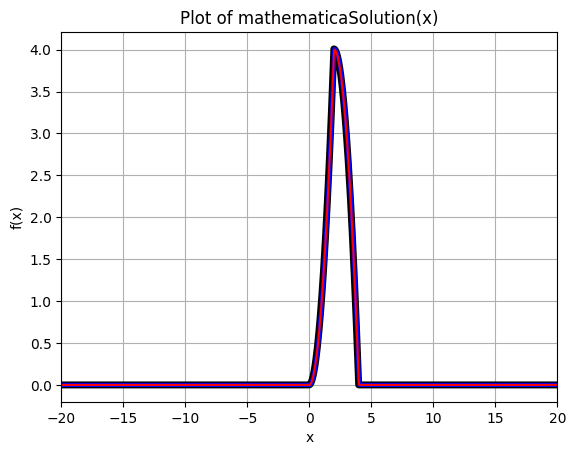

In [2]:
#Analytical Solution of Square and Triangle wave 
import numpy as np
import varConvolveGit as vcg
import inspect

def f(x):
    return np.piecewise(x, 
                        [x < 0, (0 <= x) & (x < 2), x >= 2],
                        [0, lambda x: x, 0])

def g(x):
    return np.piecewise(x, 
                        [x < 0, (0 <= x) & (x < 2), x >= 2],
                        [0, 2, 0])
    
def mathamaticaSolution(x):
    output = np.zeros(len(x))
    for i, val in enumerate(x):
        if 0<val and val<2:
            output[i] = val**2
        elif 2<=val and val<4:
            output[i] = (4*val - val **2)
        else:
            output[i] = (0)
    return output

x = np.linspace (-20,20,1000)

mathmaticaSol = mathamaticaSolution(x)

numpySol = np.convolve(f(x),g(x),mode="same") * np.diff(x)[0]

#varConSol = vcg.varconvolve(x,f(x),g,vcg.var)

convolvedSigKernArray = pc.convolution_2d_changing_kernel(f(x), g, x,1)

plt.plot(x,convolvedSigKernArray,linewidth=5, color = "black")
plt.plot(x,numpySol,linewidth=3,color = "blue")
plt.plot(x,mathmaticaSol, color="red")
plt.title("Plot of mathematicaSolution(x)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.xlim(-20,20)

plt.grid(True)
plt.show()


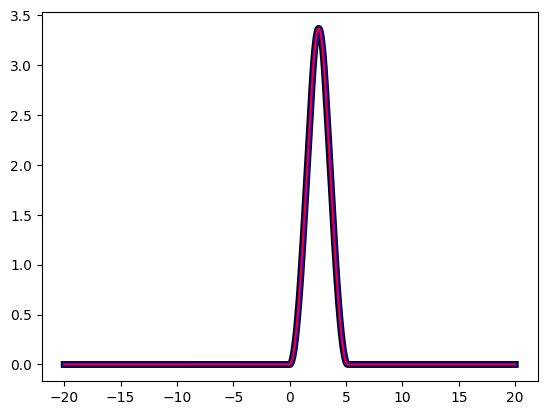

0.00040078781498054106 at 500
0.0004005736876944157 at 501
0.00040014577636577134 at 502
0.0003995047669329427 at 503
0.0003986516869277576 at 504
0.00039758790382946746 at 505
0.00039631512287269244 at 506
0.00039483538431299425 at 507
0.0003931510601578314 at 508
0.00039126485036261593 at 509
0.00038917977850413954 at 510
0.00038689918693324277 at 511
0.0003844267314164762 at 512
0.0003817663752772038 at 513
0.00037892238304126913 at 514
0.000375899313601491 at 515
0.00037270201291017546 at 516
0.0003693356062096642 at 517
0.00036580548981912653 at 518
0.0003621173224815921 at 519
0.00035827701629509434 at 520
0.0003542907272340301 at 521
0.0003501648452828299 at 522
0.0003459059841910417 at 523
0.00034152097087380984 at 524
0.00033701683446574204 at 525
0.00033240079505580944 at 526
0.00032768025211171725 at 527
0.0003228627726192812 at 528
0.000317956078953463 at 529
0.00031296803649794036 at 530
0.0003079066410380804 at 531
0.0003027800059431929 at 532
0.00029759634916182165 at 53

In [3]:
x = np.linspace(-20,20,1000)

def f(x):
    return np.piecewise(x, 
                        [x < 0, (0 <= x) & (x < 2), x >= 2],
                        [0, 2, 0])

def g(x):
    return np.piecewise(x, 
                        [x < 0, (0 <= x) & (x < np.pi), x >= np.pi],
                        [0, lambda x: np.sin(x), 0])

def mathematicaSol(x):
    x = np.array(x)  # Ensure input is NumPy array for vectorization
    return np.piecewise(x,
        [ 
            (np.pi < x) & (x < np.pi + 2),
            (0 < x) & (x < 2),
            (2 <= x) & (x <= np.pi)
        ],
        [
            lambda x: 2 * (1 + np.cos(2 - x)),
            lambda x: 2 * (1 - np.cos(x)),     # Simplified from -2*(-1 + cos(x))
            lambda x: -4 * np.sin(1) * np.sin(1 - x),
            0
        ]
    )

mathSol = mathematicaSol(x)

convolvedSigKernArray = pc.convolution_2d_changing_kernel(f(x), g, x,1)

numpySol = np.convolve(f(x),g(x),mode="same") * np.diff(x)[0]

plt.plot(x, convolvedSigKernArray,linewidth=5, color= "black")
plt.plot(x, numpySol, linewidth = 3, color = "blue")
plt.plot(x, mathSol,color = "red")
plt.show()

# checking for error between all three solutions #
diffArray = []
for i in range(len(mathSol)):

    diffArray.append(mathSol[i]-convolvedSigKernArray[i])

diffArray = np.array(diffArray)

for i, array in enumerate(diffArray):
    if array != 0:
        print(array, "at", i)

print(max(diffArray))